In [2]:
#=====LOAD & RENAME=====#

import pandas as pd
from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv('/content/drive/MyDrive/Projects/Skripsi/Data-Responden-Website-SIKEDIP/Data-Responden.csv',
                 sep=';',
                 on_bad_lines='skip')

#Renable Colume Supaya Rapi
df.columns = ['Nama', 'Pendidikan', 'Pekerjaan', 'Kontak', 'Waktu',
              'Index', 'Usia', 'Jenis_Kelamin',
              'Q1','Q2','Q3','Q4','Q5','Q6','Q7',
              'Q8','Q9','Q10','Q11','Q12','Q13','Q14','Q15']

print(df.shape)
print(df.head(3))

Mounted at /content/drive
(477, 23)
           Nama Pendidikan          Pekerjaan       Kontak             Waktu  \
0  Eko Prasetyo         S1             Swasta  85764029173  20/04/2026 12:42   
1  Saskia Putri        SMA  Pelajar/Mahasiswa  81239581047  20/04/2026 12:41   
2    Ainur Rofi         S1                PNS  82157339293  17/04/2026 07:03   

   Index  Usia Jenis_Kelamin   Q1   Q2  ...  Q6   Q7   Q8   Q9  Q10  Q11  Q12  \
0  84.00    35     Laki-Laki  100   60  ...  60   80  100  100   60   80  100   
1  85.33    20     Perempuan  100   80  ...  80  100   80   60  100  100   60   
2  84.00    26     Laki-Laki  100  100  ...  60   60   80   80   80   80   80   

   Q13  Q14  Q15  
0  100   60   80  
1   80  100   80  
2  100   80  100  

[3 rows x 23 columns]


In [3]:
#===== CLEANING & DROP =====#

# Kolom yang tidak relevan sama sekali
drop_cols = ['Nama', 'Kontak', 'Waktu']
df = df.drop(columns=drop_cols)

# Pisahkan fitur clustering dan demografi
q_cols = ['Q1','Q2','Q3','Q4','Q5','Q6','Q7','Q8','Q9','Q10','Q11','Q12','Q13','Q14','Q15']
demo_cols = ['Pendidikan', 'Pekerjaan', 'Usia', 'Jenis_Kelamin', 'Index']

X = df[q_cols]        # Ini yang masuk clustering
demo = df[demo_cols]  # Ini untuk interpretasi nanti

print("Shape X (fitur clustering):", X.shape)
print("Shape demo:", demo.shape)
print()
print(X.head(3))

Shape X (fitur clustering): (477, 15)
Shape demo: (477, 5)

    Q1   Q2   Q3   Q4   Q5  Q6   Q7   Q8   Q9  Q10  Q11  Q12  Q13  Q14  Q15
0  100   60   80  100  100  60   80  100  100   60   80  100  100   60   80
1  100   80  100  100   60  80  100   80   60  100  100   60   80  100   80
2  100  100   80  100   80  60   60   80   80   80   80   80  100   80  100


In [4]:
#===== Normalisasi menggunakan Standard Scaling (Z-score) =====#

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Sebelum scaling - mean Q1:", X['Q1'].mean().round(2))
print("Sesudah scaling - mean Q1:", X_scaled[:, 0].mean().round(2))
print("Sesudah scaling - std Q1 :", X_scaled[:, 0].std().round(2))

Sebelum scaling - mean Q1: 80.38
Sesudah scaling - mean Q1: 0.0
Sesudah scaling - std Q1 : 1.0


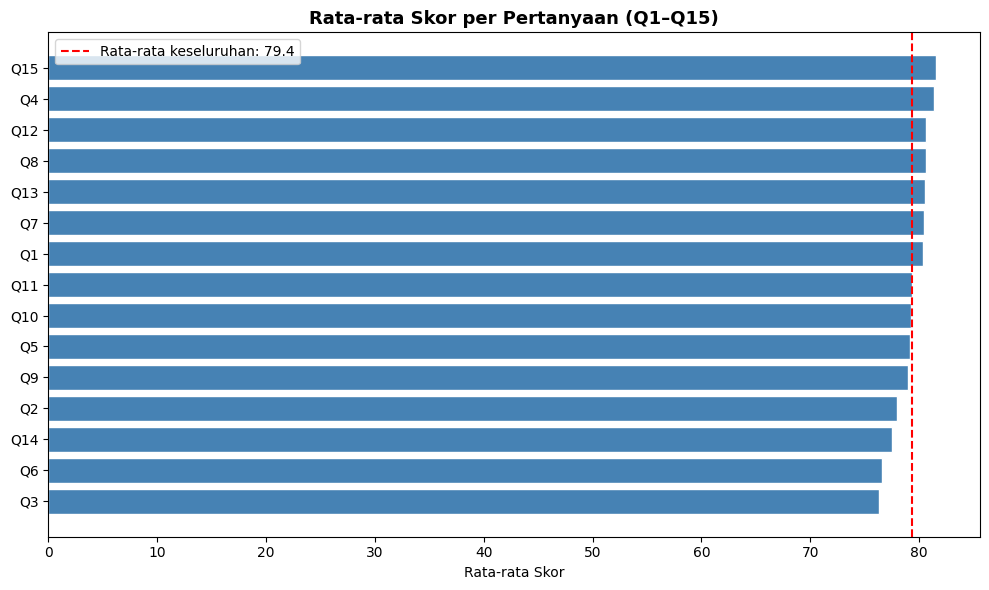

In [5]:
#===== EDA (Exploratory Data Analysis) =====#

import matplotlib.pyplot as plt
import seaborn as sns

# Rata-rata skor tiap pertanyaan
q_means = X.mean().sort_values()

plt.figure(figsize=(10, 6))
bars = plt.barh(q_means.index, q_means.values, color='steelblue', edgecolor='white')
plt.axvline(X.mean().mean(), color='red', linestyle='--', label=f'Rata-rata keseluruhan: {X.mean().mean():.1f}')
plt.title('Rata-rata Skor per Pertanyaan (Q1–Q15)', fontsize=13, fontweight='bold')
plt.xlabel('Rata-rata Skor')
plt.legend()
plt.tight_layout()
plt.show()

In [6]:
#===== Clustering K-Means =====#

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

inertias = []
sil_scores = []
K_range = range(2, 9)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, km.labels_))

print("K | Inertia | Silhouette")
for k, inertia, sil in zip(K_range, inertias, sil_scores):
    print(f"{k} | {inertia:.2f}  | {sil:.3f}")

K | Inertia | Silhouette
2 | 5516.10  | 0.201
3 | 5057.97  | 0.161
4 | 4652.49  | 0.137
5 | 4413.12  | 0.145
6 | 4221.86  | 0.127
7 | 4057.12  | 0.135
8 | 3904.21  | 0.135


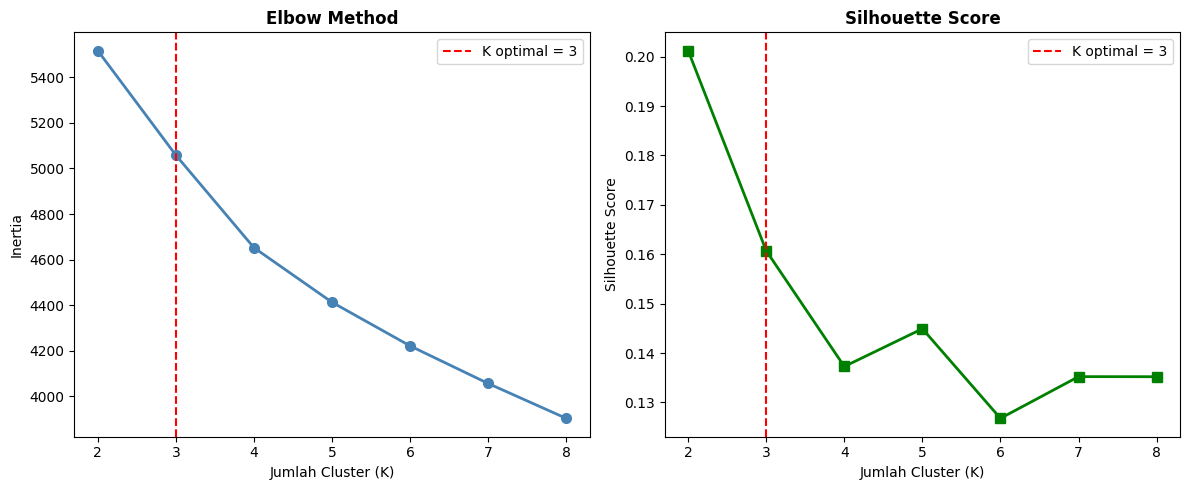

In [7]:
#===== visualisasikan =====#

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Elbow
ax1.plot(K_range, inertias, 'o-', color='steelblue', linewidth=2, markersize=7)
ax1.axvline(x=3, color='red', linestyle='--', label='K optimal = 3')
ax1.set_title('Elbow Method', fontweight='bold')
ax1.set_xlabel('Jumlah Cluster (K)')
ax1.set_ylabel('Inertia')
ax1.legend()

# Silhouette
ax2.plot(K_range, sil_scores, 's-', color='green', linewidth=2, markersize=7)
ax2.axvline(x=3, color='red', linestyle='--', label='K optimal = 3')
ax2.set_title('Silhouette Score', fontweight='bold')
ax2.set_xlabel('Jumlah Cluster (K)')
ax2.set_ylabel('Silhouette Score')
ax2.legend()

plt.tight_layout()
plt.show()

In [8]:
#===== Final Clustering dengan K=3 =====#

km_final = KMeans(n_clusters=3, random_state=42, n_init=10)
df['Cluster'] = km_final.fit_predict(X_scaled)

print(df['Cluster'].value_counts())

Cluster
0    200
2    169
1    108
Name: count, dtype: int64


In [9]:
#===== Interpretasi Cluster =====#

# Gabungkan cluster dengan demografi
cluster_profile = df.groupby('Cluster')[['Index'] + q_cols].mean().round(2)
print(cluster_profile)

         Index     Q1     Q2     Q3     Q4     Q5     Q6     Q7     Q8     Q9  \
Cluster                                                                         
0        85.64  88.00  82.90  85.00  86.50  81.30  87.20  88.50  82.80  82.60   
1        83.98  87.96  75.00  76.67  93.52  94.07  67.04  82.04  94.26  89.63   
2        69.01  66.51  73.96  65.68  67.57  67.10  70.18  69.82  69.23  67.93   

           Q10    Q11    Q12    Q13    Q14    Q15  
Cluster                                            
0        91.50  86.20  81.90  86.00  86.10  88.10  
1        69.44  85.00  94.63  84.44  77.41  88.52  
2        71.01  67.69  70.18  71.60  67.46  69.23  


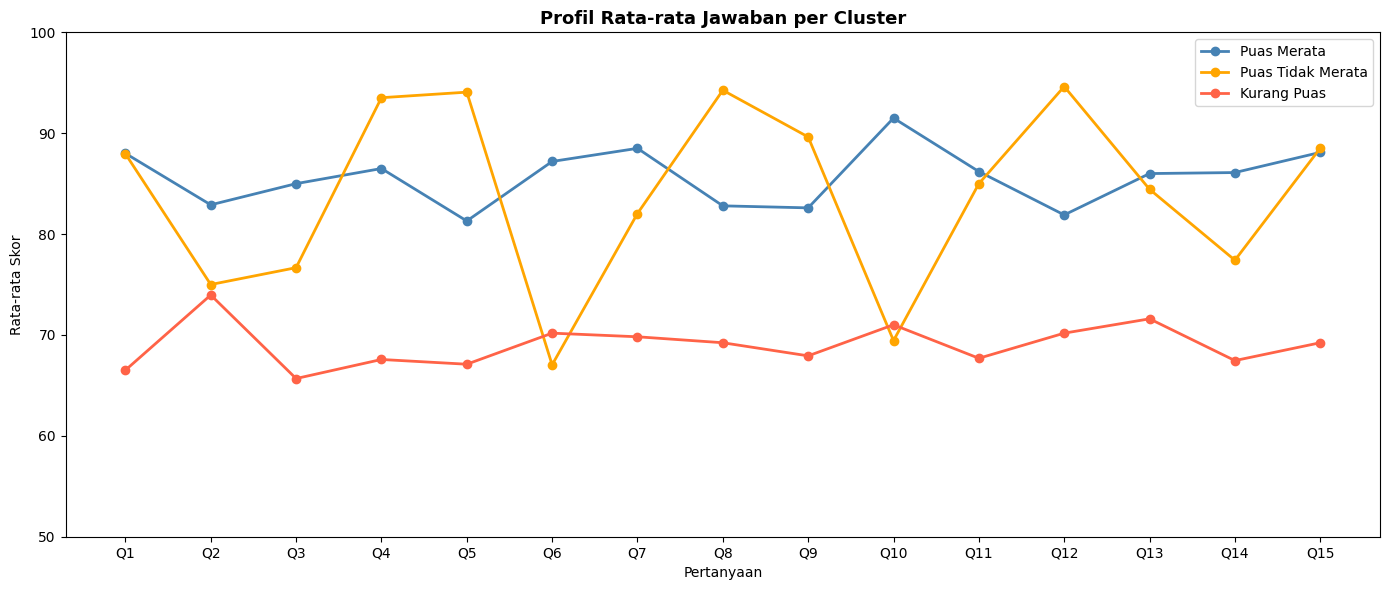

In [10]:
#===== visualisasikan profil ketiga cluster =====#

import numpy as np

cluster_names = {0: 'Puas Merata', 1: 'Puas Tidak Merata', 2: 'Kurang Puas'}
colors = {0: 'steelblue', 1: 'orange', 2: 'tomato'}

plt.figure(figsize=(14, 6))
for cluster in [0, 1, 2]:
    data = cluster_profile.loc[cluster, q_cols]
    plt.plot(q_cols, data, marker='o', linewidth=2,
             label=cluster_names[cluster], color=colors[cluster])

plt.title('Profil Rata-rata Jawaban per Cluster', fontweight='bold', fontsize=13)
plt.xlabel('Pertanyaan')
plt.ylabel('Rata-rata Skor')
plt.ylim(50, 100)
plt.legend()
plt.tight_layout()
plt.show()

In [11]:
#===== Demografi di tiap cluster =====#

for cluster in [0, 1, 2]:
    sub = df[df['Cluster'] == cluster]
    print(f"\n{'='*40}")
    print(f"Cluster {cluster} — {cluster_names[cluster]} (n={len(sub)})")
    print(f"Index rata-rata : {sub['Index'].mean():.2f}")
    print(f"Pekerjaan dominan : {sub['Pekerjaan'].value_counts().index[0]}")
    print(f"Pendidikan dominan: {sub['Pendidikan'].value_counts().index[0]}")
    print(f"Usia rata-rata  : {sub['Usia'].mean():.1f} tahun")
    print(f"Gender dominan  : {sub['Jenis_Kelamin'].value_counts().index[0]}")


Cluster 0 — Puas Merata (n=200)
Index rata-rata : 85.64
Pekerjaan dominan : Pelajar/Mahasiswa
Pendidikan dominan: S1
Usia rata-rata  : 42.0 tahun
Gender dominan  : Laki-Laki

Cluster 1 — Puas Tidak Merata (n=108)
Index rata-rata : 83.98
Pekerjaan dominan : Pelajar/Mahasiswa
Pendidikan dominan: S1
Usia rata-rata  : 29.7 tahun
Gender dominan  : Laki-Laki

Cluster 2 — Kurang Puas (n=169)
Index rata-rata : 69.01
Pekerjaan dominan : Pelajar/Mahasiswa
Pendidikan dominan: S1
Usia rata-rata  : 42.6 tahun
Gender dominan  : Laki-Laki


In [12]:
#===== Validasi statistik =====#

import scipy.stats as stats

print("Uji Kruskal-Wallis — Perbedaan Index antar Cluster\n")
groups = [df[df['Cluster'] == c]['Index'].values for c in [0, 1, 2]]
stat, p = stats.kruskal(*groups)
print(f"Statistik : {stat:.3f}")
print(f"P-value   : {p:.6f}")

if p < 0.05:
    print("\n✅ Ketiga cluster berbeda secara signifikan (p < 0.05)")
else:
    print("\n❌ Tidak ada perbedaan signifikan antar cluster")

Uji Kruskal-Wallis — Perbedaan Index antar Cluster

Statistik : 326.683
P-value   : 0.000000

✅ Ketiga cluster berbeda secara signifikan (p < 0.05)


In [13]:
#===== SHapley Additive Explanations =====#

from sklearn.ensemble import RandomForestClassifier

X_shap = df[q_cols]
y_shap = df['Cluster']

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_shap, y_shap)

print("Akurasi model:", round(rf.score(X_shap, y_shap), 3))

Akurasi model: 1.0


In [14]:
#===== SHAP - Explainability : tahap kalkulasi SHAP =====#

import shap

explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_shap)

print("Jumlah cluster:", len(shap_values))
print("Shape per cluster:", shap_values[0].shape)

Jumlah cluster: 477
Shape per cluster: (15, 3)


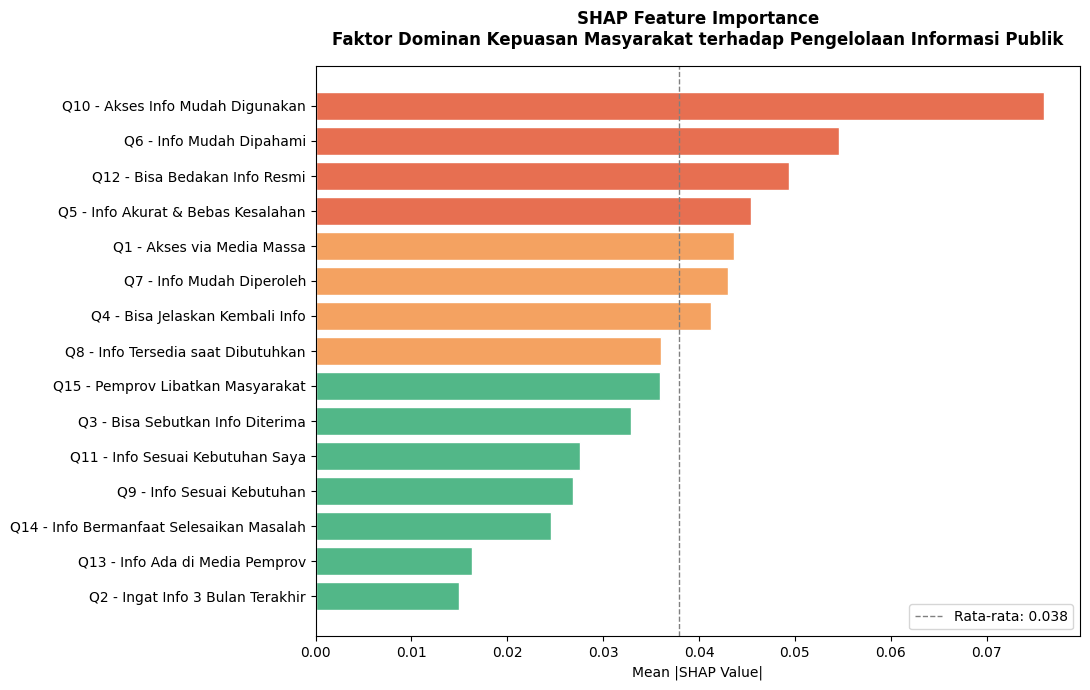

In [15]:
#===== SHAP - Visualisasi Feature Importance =====#

q_labels = {
    'Q1' : 'Q1 - Akses via Media Massa',
    'Q2' : 'Q2 - Ingat Info 3 Bulan Terakhir',
    'Q3' : 'Q3 - Bisa Sebutkan Info Diterima',
    'Q4' : 'Q4 - Bisa Jelaskan Kembali Info',
    'Q5' : 'Q5 - Info Akurat & Bebas Kesalahan',
    'Q6' : 'Q6 - Info Mudah Dipahami',
    'Q7' : 'Q7 - Info Mudah Diperoleh',
    'Q8' : 'Q8 - Info Tersedia saat Dibutuhkan',
    'Q9' : 'Q9 - Info Sesuai Kebutuhan',
    'Q10': 'Q10 - Akses Info Mudah Digunakan',
    'Q11': 'Q11 - Info Sesuai Kebutuhan Saya',
    'Q12': 'Q12 - Bisa Bedakan Info Resmi',
    'Q13': 'Q13 - Info Ada di Media Pemprov',
    'Q14': 'Q14 - Info Bermanfaat Selesaikan Masalah',
    'Q15': 'Q15 - Pemprov Libatkan Masyarakat',
}

shap_array = np.array(shap_values)
mean_shap = np.abs(shap_array).mean(axis=(0, 2))

shap_df = pd.DataFrame({
    'fitur'     : q_cols,
    'label'     : [q_labels[q] for q in q_cols],
    'importance': mean_shap
}).sort_values('importance')

fig, ax = plt.subplots(figsize=(11, 7))
colors = ['#E76F51' if v >= shap_df['importance'].quantile(0.75) else
          '#F4A261' if v >= shap_df['importance'].median() else
          '#52B788' for v in shap_df['importance']]

ax.barh(shap_df['label'], shap_df['importance'], color=colors, edgecolor='white')
ax.set_title('SHAP Feature Importance\nFaktor Dominan Kepuasan Masyarakat terhadap Pengelolaan Informasi Publik',
             fontsize=12, fontweight='bold', pad=15)
ax.set_xlabel('Mean |SHAP Value|')
ax.axvline(mean_shap.mean(), color='gray', linestyle='--',
           linewidth=1, label=f'Rata-rata: {mean_shap.mean():.3f}')
ax.legend()
plt.tight_layout()
plt.show()

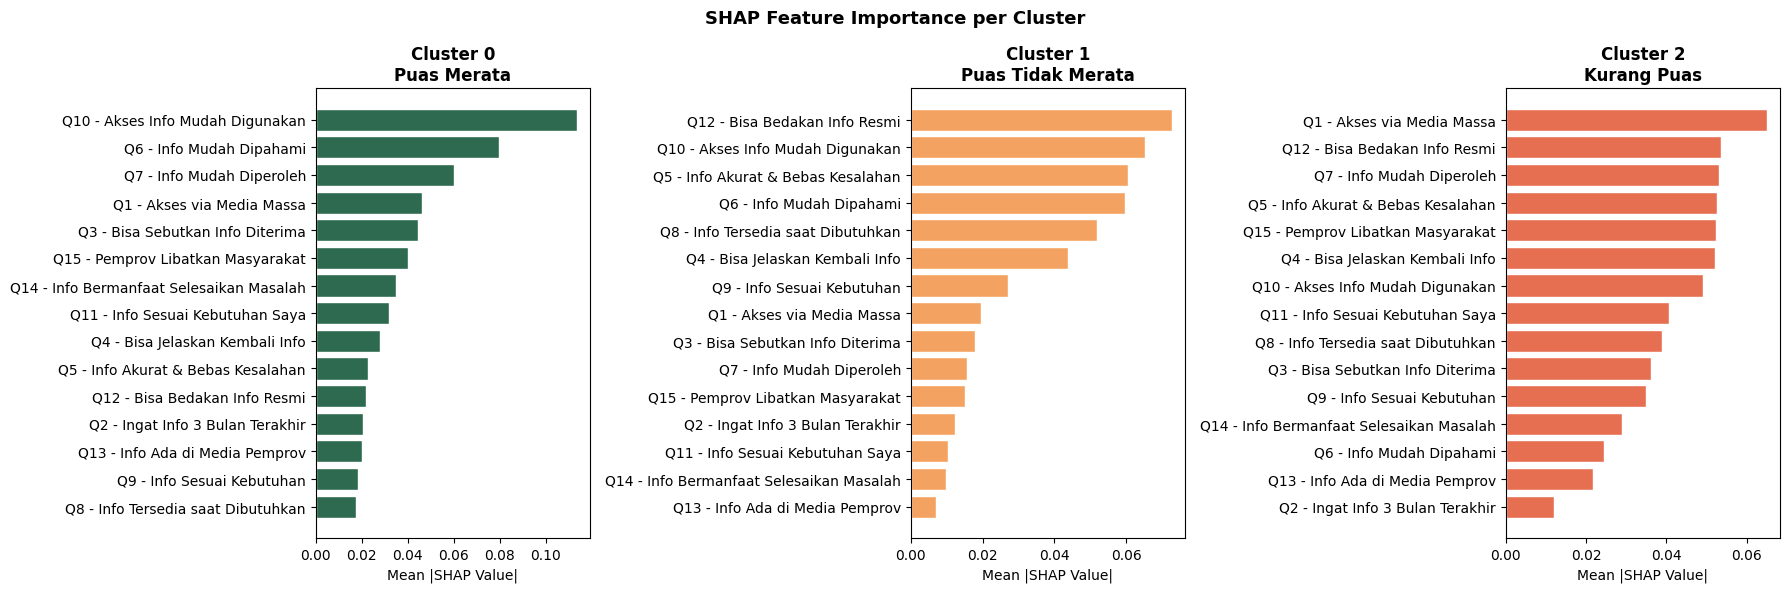

In [16]:
#===== SHAP - Per Cluster =====#

cluster_names = {0: 'Puas Merata', 1: 'Puas Tidak Merata', 2: 'Kurang Puas'}
colors_cluster = {0: '#2D6A4F', 1: '#F4A261', 2: '#E76F51'}

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('SHAP Feature Importance per Cluster', fontsize=13, fontweight='bold')

for i, cluster in enumerate([0, 1, 2]):
    mean_shap_c = np.abs(shap_array[:, :, cluster]).mean(axis=0)
    shap_c = pd.DataFrame({
        'label': [q_labels[q] for q in q_cols],
        'importance': mean_shap_c
    }).sort_values('importance')

    axes[i].barh(shap_c['label'], shap_c['importance'],
                 color=colors_cluster[cluster], edgecolor='white')
    axes[i].set_title(f"Cluster {cluster}\n{cluster_names[cluster]}",
                      fontweight='bold')
    axes[i].set_xlabel('Mean |SHAP Value|')

plt.tight_layout()
plt.show()

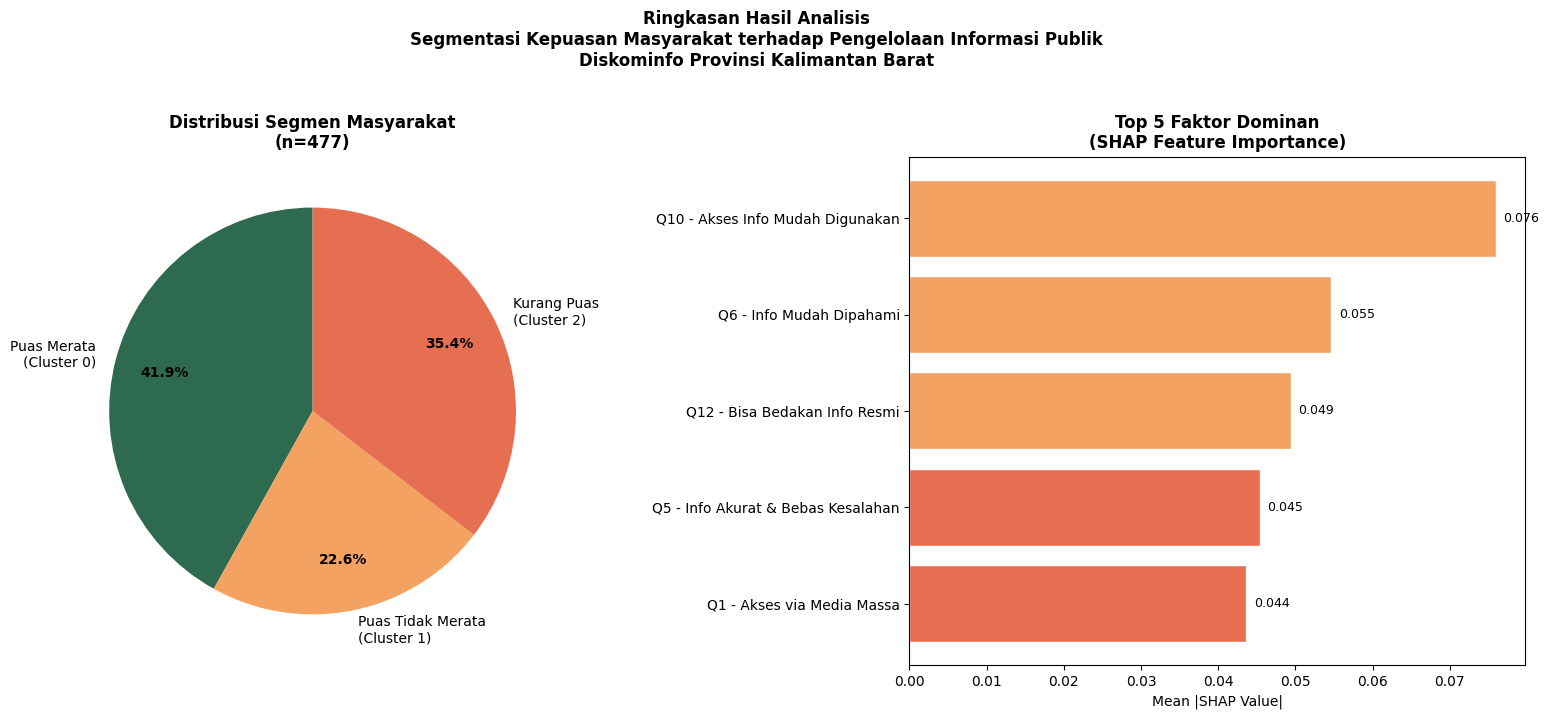

In [17]:
#===== Visualisasi Final - Summary =====#

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Ringkasan Hasil Analisis\nSegmentasi Kepuasan Masyarakat terhadap Pengelolaan Informasi Publik\nDiskominfo Provinsi Kalimantan Barat',
             fontsize=12, fontweight='bold', y=1.02)

# Kiri — Distribusi cluster
cluster_counts = df['Cluster'].value_counts().sort_index()
cluster_labels = ['Puas Merata\n(Cluster 0)',
                  'Puas Tidak Merata\n(Cluster 1)',
                  'Kurang Puas\n(Cluster 2)']
cluster_colors = ['#2D6A4F', '#F4A261', '#E76F51']

wedges, texts, autotexts = axes[0].pie(
    cluster_counts.values,
    labels=cluster_labels,
    autopct='%1.1f%%',
    colors=cluster_colors,
    startangle=90,
    pctdistance=0.75
)
for at in autotexts:
    at.set_fontsize(10)
    at.set_fontweight('bold')
axes[0].set_title('Distribusi Segmen Masyarakat\n(n=477)', fontweight='bold')

# Kanan — Top 5 faktor dominan keseluruhan
top5 = shap_df.tail(5)
bar_colors = ['#E76F51','#E76F51','#F4A261','#F4A261','#F4A261']
axes[1].barh(top5['label'], top5['importance'],
             color=bar_colors, edgecolor='white')
axes[1].set_title('Top 5 Faktor Dominan\n(SHAP Feature Importance)', fontweight='bold')
axes[1].set_xlabel('Mean |SHAP Value|')
for i, (val, label) in enumerate(zip(top5['importance'], top5['label'])):
    axes[1].text(val + 0.001, i, f'{val:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

In [18]:
#===== Kesimpulan & Rekomendasi =====#

kesimpulan = """
╔══════════════════════════════════════════════════════════════════╗
║           KESIMPULAN PENELITIAN                                  ║
╠══════════════════════════════════════════════════════════════════╣
║                                                                  ║
║  DATA   : 477 responden · SKM Diskominfo Kalbar 2023-2026        ║
║  METODE : K-Means Clustering + SHAP Explainability               ║
║                                                                  ║
╠══════════════════════════════════════════════════════════════════╣
║  SEGMENTASI MASYARAKAT (K=3)                                     ║
║                                                                  ║
║  Cluster 0 · Puas Merata       → 200 responden (41.9%)          ║
║  Cluster 1 · Puas Tidak Merata → 108 responden (22.6%)          ║
║  Cluster 2 · Kurang Puas       → 169 responden (35.4%)          ║
║                                                                  ║
╠══════════════════════════════════════════════════════════════════╣
║  TOP 5 FAKTOR DOMINAN (SHAP)                                     ║
║                                                                  ║
║  1. Q10 - Kemudahan Akses Informasi          (0.076)            ║
║  2. Q6  - Kemudahan Memahami Informasi       (0.055)            ║
║  3. Q12 - Identifikasi Info Resmi            (0.049)            ║
║  4. Q5  - Akurasi Informasi                  (0.045)            ║
║  5. Q1  - Akses via Media Massa              (0.044)            ║
║                                                                  ║
╠══════════════════════════════════════════════════════════════════╣
║  REKOMENDASI UNTUK DISKOMINFO                                    ║
║                                                                  ║
║  1. Prioritaskan kemudahan akses platform SIKEDIP (Q10)         ║
║  2. Tingkatkan keterbacaan & kejelasan konten (Q6)              ║
║  3. Perkuat branding info resmi vs hoaks (Q12)                  ║
║  4. Jaga akurasi & verifikasi konten (Q5)                       ║
║  5. Perluas jangkauan via media massa (Q1)                      ║
║                                                                  ║
╠══════════════════════════════════════════════════════════════════╣
║  TEMUAN UTAMA                                                    ║
║                                                                  ║
║  · Demografi bukan penentu kepuasan — pola penilaian iya        ║
║  · 35.4% masyarakat masih Kurang Puas — perlu perhatian         ║
║  · Kemudahan akses > konten dalam menentukan kepuasan           ║
║  · Tiap cluster punya faktor dominan yang berbeda               ║
║                                                                  ║
╚══════════════════════════════════════════════════════════════════╝
"""
print(kesimpulan)


╔══════════════════════════════════════════════════════════════════╗
║           KESIMPULAN PENELITIAN                                  ║
╠══════════════════════════════════════════════════════════════════╣
║                                                                  ║
║  DATA   : 477 responden · SKM Diskominfo Kalbar 2023-2026        ║
║  METODE : K-Means Clustering + SHAP Explainability               ║
║                                                                  ║
╠══════════════════════════════════════════════════════════════════╣
║  SEGMENTASI MASYARAKAT (K=3)                                     ║
║                                                                  ║
║  Cluster 0 · Puas Merata       → 200 responden (41.9%)          ║
║  Cluster 1 · Puas Tidak Merata → 108 responden (22.6%)          ║
║  Cluster 2 · Kurang Puas       → 169 responden (35.4%)          ║
║                                                                  ║
╠═══════════════════════════════════

In [25]:
import os

# Masuk ke 'kantor pos' (folder skripsi kamu)
%cd /content/drive/MyDrive/Projects/Skripsi

# Tandai semua kodingan/file yang baru kamu ubah hari ini
!git add .

# Bungkus dan beri label nama kegiatannya (biar rapi di GitHub)
!git commit -m "Clean up notebook cells"

# Tarik perubahan terbaru dari remote sebelum push
# Ini penting untuk menghindari konflik jika ada perubahan lain di GitHub
!git pull origin main --rebase

# Kirim ke GitHub!
!git push

/content/drive/MyDrive/Projects/Skripsi
usage: jupyter [-h] [--version] [--config-dir] [--data-dir] [--runtime-dir]
               [--paths] [--json] [--debug]
               [subcommand]

Jupyter: Interactive Computing

positional arguments:
  subcommand     the subcommand to launch

options:
  -h, --help     show this help message and exit
  --version      show the versions of core jupyter packages and exit
  --config-dir   show Jupyter config dir
  --data-dir     show Jupyter data dir
  --runtime-dir  show Jupyter runtime dir
  --paths        show all Jupyter paths. Add --json for machine-readable
                 format.
  --json         output paths as machine-readable json
  --debug        output debug information about paths

Available subcommands: bundlerextension console dejavu events execute kernel
kernelgateway kernelspec migrate nbclassic nbconvert nbextension notebook run
server serverextension troubleshoot trust

Jupyter command `jupyter-nbstripout` not found.
error: exte

### Opsional: Menggunakan `nbstripout` untuk membersihkan output sel sebelum commit

Jika Anda ingin agar output dari sel-sel (termasuk output perintah Git) tidak ikut ter-commit ke GitHub, Anda bisa menggunakan `nbstripout`. Ini adalah praktik yang baik untuk menjaga agar repositori Git Anda tetap bersih dan hanya melacak perubahan pada kode sumber, bukan pada output eksekusi.

In [26]:
# Batalkan konfigurasi nbstripout yang menyebabkan error
!git config --global --unset filter.nbstripout.clean
!git config --global --unset filter.nbstripout.smudge
!git config --global --unset filter.nbstripout.required

# Hapus file .gitattributes jika ada, yang mengaktifkan filter nbstripout
# Pastikan Anda berada di direktori repo Anda
%cd /content/drive/MyDrive/Projects/Skripsi
!rm -f .gitattributes

print("Konfigurasi nbstripout telah dibatalkan. Sekarang Anda bisa mencoba lagi operasi Git.")

/content/drive/MyDrive/Projects/Skripsi
Konfigurasi nbstripout telah dibatalkan. Sekarang Anda bisa mencoba lagi operasi Git.


In [23]:
# 1. Install nbstripout
!pip install nbstripout

# 2. Konfigurasi Git untuk menggunakan nbstripout secara otomatis untuk semua file .ipynb
!git config --global filter.nbstripout.clean "jupyter nbstripout"
!git config --global filter.nbstripout.smudge cat
!git config --global filter.nbstripout.required true

# 3. Tambahkan atribut filter ke file .gitattributes di repositori Anda
# Ini akan memastikan Git tahu untuk menggunakan nbstripout untuk file .ipynb
with open('.gitattributes', 'a') as f:
    f.write('*.ipynb filter=nbstripout')

print("nbstripout telah diinstal dan dikonfigurasi. Selanjutnya, commit dan push Anda akan otomatis membersihkan output sel.")

nbstripout telah diinstal dan dikonfigurasi. Selanjutnya, commit dan push Anda akan otomatis membersihkan output sel.


Setelah menjalankan sel di atas, Anda perlu menambahkan dan meng-commit file `.gitattributes` ini ke repositori Anda sekali saja:

```bash
!git add .gitattributes
!git commit -m "Configure nbstripout"
!git push
```

Setelah itu, setiap kali Anda mengubah notebook dan melakukan `git commit`, `nbstripout` akan secara otomatis membersihkan output sel Anda sebelum commit. File `.ipynb` di repositori GitHub Anda akan terlihat lebih rapi tanpa output yang berantakan.

In [24]:
# Tambahkan dan commit file .gitattributes
!git add .gitattributes
!git commit -m "Configure nbstripout"
!git push

[main c6a1fb9] Configure nbstripout
 1 file changed, 1 insertion(+)
 create mode 100644 .gitattributes
Enumerating objects: 4, done.
Counting objects: 100% (4/4), done.
Delta compression using up to 2 threads
Compressing objects: 100% (3/3), done.
Writing objects: 100% (3/3), 315 bytes | 52.00 KiB/s, done.
Total 3 (delta 1), reused 0 (delta 0), pack-reused 0
remote: Resolving deltas: 100% (1/1), completed with 1 local object.
To https://github.com/RizaHaryadi2003/Thesis-KMeans-Clustering.git
   d09305a..c6a1fb9  main -> main
